### **Unzippping the cleaned vaccine_data from Vaccination_EDA.ipynb**

In [ ]:
!unzip -q "/content/cleaned_vaccine_data.zip" -d "/content/cleaned_data"

## 0. Setup

In [ ]:
import os
import sqlite3
import zipfile
import numpy as np
import pandas as pd

pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 60)

BASE_DIR = "/content/cleaned_data"      # <- folder where you uploaded the cleaned CSVs
DB_PATH  = "/content/vaccination.db"    # SQL database file this notebook builds
PBI_DIR  = "/content/powerbi_exports"   # flattened tables ready for Power BI import

os.makedirs(PBI_DIR, exist_ok=True)

required_files = [
    "vaccination_coverage.csv",
    "vaccination_coverage_country_valid.csv",
    "incidence_rate.csv",
    "reported_cases.csv",
    "vaccine_introduction.csv",
    "vaccine_schedule.csv",
    "country_year_summary.csv",
]
missing = [f for f in required_files if not os.path.exists(os.path.join(BASE_DIR, f))]
assert not missing, f"Missing files in {BASE_DIR}: {missing}. Upload/unzip cleaned_vaccine_data.zip there first."
print("All 7 cleaned files found in", BASE_DIR)

All 7 cleaned files found in /content/cleaned_data


In [ ]:
# Fresh database each run
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

conn = sqlite3.connect(DB_PATH)
cur = conn.cursor()
cur.execute("PRAGMA foreign_keys = ON;")
print("Connected to", DB_PATH)

Connected to /content/vaccination.db


## 1. Load raw cleaned CSVs into staging tables

Each cleaned CSV goes into a `stg_*` table with no structural changes — this keeps a faithful, queryable copy of
the EDA output inside the database, and is the source for every dimension/fact table built below.

In [ ]:
files = {
    "stg_coverage":              "vaccination_coverage.csv",
    "stg_coverage_valid":        "vaccination_coverage_country_valid.csv",
    "stg_incidence":             "incidence_rate.csv",
    "stg_cases":                 "reported_cases.csv",
    "stg_intro":                 "vaccine_introduction.csv",
    "stg_schedule":              "vaccine_schedule.csv",
    "stg_country_year_summary":  "country_year_summary.csv",
}

dfs = {}
for table, fname in files.items():
    df = pd.read_csv(os.path.join(BASE_DIR, fname), low_memory=False)
    dfs[table] = df
    df.to_sql(table, conn, if_exists="replace", index=False)
    print(f"{table:28s} <- {fname:45s} {df.shape}")

conn.commit()

stg_coverage                 <- vaccination_coverage.csv                      (398584, 13)
stg_coverage_valid           <- vaccination_coverage_country_valid.csv        (80919, 13)
stg_incidence                <- incidence_rate.csv                            (84945, 9)
stg_cases                    <- reported_cases.csv                            (84869, 7)
stg_intro                    <- vaccine_introduction.csv                      (138320, 7)
stg_schedule                 <- vaccine_schedule.csv                          (8052, 12)
stg_country_year_summary     <- country_year_summary.csv                      (9024, 6)


## 2. Build the star schema — dimension tables

The five source tables all share `country_code` / `year`, and the coverage table additionally carries an
antigen, while the incidence/cases tables carry a disease. That is normalized into:

- `dim_country` — one row per country, with its WHO region attached
- `dim_who_region` — WHO region code ↔ full name lookup
- `dim_antigen` — every vaccine/antigen code used in the coverage table
- `dim_disease` — every disease code used in the incidence/cases tables
- `dim_vaccine` — every vaccine code used in the national schedule table
- `dim_antigen_disease_map` — a reference bridge table pairing a coverage antigen with the disease(s) it protects
  against (e.g. `MCV1` → `MEASLES`), built from public WHO/CDC vaccine-preventable-disease knowledge since the
  raw data does not label this relationship itself. This is what makes "coverage vs. incidence" questions joinable.
- `dim_intro_disease_map` — the same idea for the *vaccine introduction* table, whose vaccine names differ from
  the antigen codes (e.g. `"Measles-containing vaccine 2nd dose"` → `MEASLES`).

In [ ]:
# WHO region code <-> full name (coverage/incidence/cases use full names for their region rollups;
# intro/schedule use the abbreviations)
dim_who_region = pd.DataFrame([
    ("AFRO", "African Region"),
    ("AMRO", "Region of the Americas"),
    ("EMRO", "Eastern Mediterranean Region"),
    ("EURO", "European Region"),
    ("SEARO", "South-East Asia Region"),
    ("WPRO", "Western Pacific Region"),
], columns=["who_region_code", "who_region_name"])
dim_who_region.to_sql("dim_who_region", conn, if_exists="replace", index=False)

# dim_country: country_code (PK), country_name, who_region_code
country_names = dfs["stg_coverage_valid"][["country_code", "country_name"]].drop_duplicates()
region_lookup = pd.concat([
    dfs["stg_intro"][["country_code", "WHO_REGION"]],
    dfs["stg_schedule"][["country_code", "WHO_REGION"]],
]).drop_duplicates().rename(columns={"WHO_REGION": "who_region_code"}).drop_duplicates(subset="country_code")

dim_country = country_names.merge(region_lookup, on="country_code", how="left")
dim_country.to_sql("dim_country", conn, if_exists="replace", index=False)
print("dim_country:", dim_country.shape, "| missing WHO region:", dim_country.who_region_code.isna().sum())

# dim_antigen
dim_antigen = (dfs["stg_coverage"][["ANTIGEN", "ANTIGEN_DESCRIPTION"]]
               .drop_duplicates().dropna(subset=["ANTIGEN"]).drop_duplicates(subset="ANTIGEN")
               .rename(columns={"ANTIGEN": "antigen_code", "ANTIGEN_DESCRIPTION": "antigen_description"}))
dim_antigen.to_sql("dim_antigen", conn, if_exists="replace", index=False)
print("dim_antigen:", dim_antigen.shape)

# dim_disease (union of incidence + cases disease codes)
dim_disease = (pd.concat([
    dfs["stg_incidence"][["DISEASE", "DISEASE_DESCRIPTION"]],
    dfs["stg_cases"][["DISEASE", "DISEASE_DESCRIPTION"]],
]).drop_duplicates().drop_duplicates(subset="DISEASE")
   .rename(columns={"DISEASE": "disease_code", "DISEASE_DESCRIPTION": "disease_description"}))
dim_disease.to_sql("dim_disease", conn, if_exists="replace", index=False)
print("dim_disease:", dim_disease.shape)

# dim_vaccine (from the national schedule table)
dim_vaccine = (dfs["stg_schedule"][["VACCINECODE", "VACCINE_DESCRIPTION"]]
               .drop_duplicates().drop_duplicates(subset="VACCINECODE")
               .rename(columns={"VACCINECODE": "vaccine_code", "VACCINE_DESCRIPTION": "vaccine_description"}))
dim_vaccine.to_sql("dim_vaccine", conn, if_exists="replace", index=False)
print("dim_vaccine:", dim_vaccine.shape)

# dim_antigen_disease_map: coverage antigen -> disease(s) it targets (reference knowledge, not derived from data)
dim_antigen_disease_map = pd.DataFrame([
    ("MCV1", "MEASLES"), ("MCV2", "MEASLES"),
    ("DTPCV1", "DIPHTHERIA"), ("DTPCV3", "DIPHTHERIA"),
    ("DTPCV1", "PERTUSSIS"), ("DTPCV3", "PERTUSSIS"),
    ("DTPCV1", "NTETANUS"), ("DTPCV3", "NTETANUS"),
    ("DTPCV1", "TTETANUS"), ("DTPCV3", "TTETANUS"),
    ("POL3", "POLIO"), ("IPV1", "POLIO"), ("IPV2", "POLIO"),
    ("RCV1", "RUBELLA"), ("RCV1", "CRS"),
    ("YFV", "YFEVER"),
    ("MENA_C", "INVASIVE_MENING"),
], columns=["antigen_code", "disease_code"])
dim_antigen_disease_map.to_sql("dim_antigen_disease_map", conn, if_exists="replace", index=False)

# dim_intro_disease_map: vaccine-introduction vaccine name -> disease code
dim_intro_disease_map = pd.DataFrame([
    ("Measles-containing vaccine 2nd dose", "MEASLES"),
    ("YF (Yellow fever) vaccine", "YFEVER"),
    ("Rubella vaccine", "RUBELLA"),
    ("Mumps vaccine", "MUMPS"),
    ("Typhoid", "TYPHOID"),
    ("Japanese Encephalitis", "JAPENC"),
    ("Meningococcal meningitis vaccines (all strains)", "INVASIVE_MENING"),
], columns=["vaccine_name", "disease_code"])
dim_intro_disease_map.to_sql("dim_intro_disease_map", conn, if_exists="replace", index=False)

conn.commit()
print("dim_antigen_disease_map:", dim_antigen_disease_map.shape, "| dim_intro_disease_map:", dim_intro_disease_map.shape)

dim_country: (195, 3) | missing WHO region: 0
dim_antigen: (69, 2)
dim_disease: (13, 2)
dim_vaccine: (86, 2)
dim_antigen_disease_map: (17, 2) | dim_intro_disease_map: (7, 2)


## 3. Build the fact tables

Country-level rows are the primary analysis grain (`LEVEL='COUNTRY'` / `GROUP='COUNTRIES'`). WHO-region and
global rollups already published in the source data are kept as their own fact tables rather than re-aggregated,
so they match WHO's own published regional/global figures.

`fact_coverage` keeps **every** coverage category (`ADMIN`, `OFFICIAL`, `WUENIC`, `HPV`, `PAB`) and keeps the
`is_invalid` flag from the EDA step (coverage > 100%) rather than silently dropping those rows — filter on it
per-query as needed. Most "coverage" questions below use `coverage_category='WUENIC' AND is_invalid=0`, which is
exactly the WHO/UNICEF joint estimate — the same one used in `vaccination_coverage_country_valid.csv`.

In [ ]:
# ---- coverage ---------------------------------------------------------
fact_coverage = dfs["stg_coverage"][dfs["stg_coverage"]["LEVEL"] == "COUNTRY"][[
    "country_code", "year", "ANTIGEN", "COVERAGE_CATEGORY", "TARGET_NUMBER", "DOSES",
    "COVERAGE", "COVERAGE_FLAG_INVALID"
]].rename(columns={
    "ANTIGEN": "antigen_code", "COVERAGE_CATEGORY": "coverage_category",
    "TARGET_NUMBER": "target_number", "DOSES": "doses", "COVERAGE": "coverage",
    "COVERAGE_FLAG_INVALID": "is_invalid",
})
fact_coverage.insert(0, "coverage_id", range(1, len(fact_coverage) + 1))
fact_coverage.to_sql("fact_coverage", conn, if_exists="replace", index=False)

fact_coverage_region = dfs["stg_coverage"][dfs["stg_coverage"]["GROUP"] == "WHO_REGIONS"][[
    "country_name", "year", "ANTIGEN", "COVERAGE_CATEGORY", "TARGET_NUMBER", "DOSES", "COVERAGE"
]].rename(columns={"country_name": "who_region_name", "ANTIGEN": "antigen_code",
                    "COVERAGE_CATEGORY": "coverage_category", "TARGET_NUMBER": "target_number",
                    "DOSES": "doses", "COVERAGE": "coverage"})
fact_coverage_region = fact_coverage_region.merge(dim_who_region, on="who_region_name", how="left")
fact_coverage_region.to_sql("fact_coverage_region", conn, if_exists="replace", index=False)

fact_coverage_global = dfs["stg_coverage"][dfs["stg_coverage"]["GROUP"] == "GLOBAL"][[
    "year", "ANTIGEN", "COVERAGE_CATEGORY", "TARGET_NUMBER", "DOSES", "COVERAGE"
]].rename(columns={"ANTIGEN": "antigen_code", "COVERAGE_CATEGORY": "coverage_category",
                    "TARGET_NUMBER": "target_number", "DOSES": "doses", "COVERAGE": "coverage"})
fact_coverage_global.to_sql("fact_coverage_global", conn, if_exists="replace", index=False)

# ---- incidence ----------------------------------------------------------
fact_incidence = dfs["stg_incidence"][dfs["stg_incidence"]["GROUP"] == "COUNTRIES"][[
    "country_code", "year", "DISEASE", "DENOMINATOR_CLEAN", "INCIDENCE_RATE"
]].rename(columns={"DISEASE": "disease_code", "DENOMINATOR_CLEAN": "denominator", "INCIDENCE_RATE": "incidence_rate"})
fact_incidence.insert(0, "incidence_id", range(1, len(fact_incidence) + 1))
fact_incidence.to_sql("fact_incidence", conn, if_exists="replace", index=False)

fact_incidence_region = dfs["stg_incidence"][dfs["stg_incidence"]["GROUP"] == "WHO_REGIONS"][[
    "country_name", "year", "DISEASE", "DENOMINATOR_CLEAN", "INCIDENCE_RATE"
]].rename(columns={"country_name": "who_region_name", "DISEASE": "disease_code",
                    "DENOMINATOR_CLEAN": "denominator", "INCIDENCE_RATE": "incidence_rate"})
fact_incidence_region = fact_incidence_region.merge(dim_who_region, on="who_region_name", how="left")
fact_incidence_region.to_sql("fact_incidence_region", conn, if_exists="replace", index=False)

fact_incidence_global = dfs["stg_incidence"][dfs["stg_incidence"]["GROUP"] == "GLOBAL"][[
    "year", "DISEASE", "DENOMINATOR_CLEAN", "INCIDENCE_RATE"
]].rename(columns={"DISEASE": "disease_code", "DENOMINATOR_CLEAN": "denominator", "INCIDENCE_RATE": "incidence_rate"})
fact_incidence_global.to_sql("fact_incidence_global", conn, if_exists="replace", index=False)

# ---- reported cases -------------------------------------------------------
fact_cases = dfs["stg_cases"][dfs["stg_cases"]["GROUP"] == "COUNTRIES"][[
    "country_code", "year", "DISEASE", "CASES"
]].rename(columns={"DISEASE": "disease_code", "CASES": "cases"})
fact_cases.insert(0, "case_id", range(1, len(fact_cases) + 1))
fact_cases.to_sql("fact_cases", conn, if_exists="replace", index=False)

fact_cases_region = dfs["stg_cases"][dfs["stg_cases"]["GROUP"] == "WHO_REGIONS"][[
    "country_name", "year", "DISEASE", "CASES"
]].rename(columns={"country_name": "who_region_name", "DISEASE": "disease_code", "CASES": "cases"})
fact_cases_region = fact_cases_region.merge(dim_who_region, on="who_region_name", how="left")
fact_cases_region.to_sql("fact_cases_region", conn, if_exists="replace", index=False)

fact_cases_global = dfs["stg_cases"][dfs["stg_cases"]["GROUP"] == "GLOBAL"][[
    "year", "DISEASE", "CASES"
]].rename(columns={"DISEASE": "disease_code", "CASES": "cases"})
fact_cases_global.to_sql("fact_cases_global", conn, if_exists="replace", index=False)

# ---- vaccine introduction & schedule --------------------------------------
fact_vaccine_introduction = dfs["stg_intro"].rename(columns={
    "WHO_REGION": "who_region_code", "DESCRIPTION": "vaccine_name", "INTRO_CLEAN": "intro_status",
})[["country_code", "year", "who_region_code", "vaccine_name", "intro_status"]]
fact_vaccine_introduction.insert(0, "intro_id", range(1, len(fact_vaccine_introduction) + 1))
fact_vaccine_introduction.to_sql("fact_vaccine_introduction", conn, if_exists="replace", index=False)

fact_vaccine_schedule = dfs["stg_schedule"].rename(columns={
    "WHO_REGION": "who_region_code", "VACCINECODE": "vaccine_code", "SCHEDULEROUNDS": "schedule_round",
    "TARGETPOP": "target_pop", "TARGETPOP_DESCRIPTION": "target_pop_description", "GEOAREA": "geoarea",
    "AGEADMINISTERED": "age_administered", "SOURCECOMMENT": "source_comment",
})[["country_code", "year", "who_region_code", "vaccine_code", "schedule_round", "target_pop",
    "target_pop_description", "geoarea", "age_administered", "source_comment"]]
fact_vaccine_schedule.insert(0, "schedule_id", range(1, len(fact_vaccine_schedule) + 1))
fact_vaccine_schedule.to_sql("fact_vaccine_schedule", conn, if_exists="replace", index=False)

# ---- pre-built country-year summary (from the EDA step) -------------------
agg_country_year_summary = dfs["stg_country_year_summary"].merge(
    dim_country[["country_code", "who_region_code"]], on="country_code", how="left"
)
agg_country_year_summary.to_sql("agg_country_year_summary", conn, if_exists="replace", index=False)

conn.commit()
for t in ["fact_coverage","fact_coverage_region","fact_coverage_global","fact_incidence",
          "fact_incidence_region","fact_incidence_global","fact_cases","fact_cases_region",
          "fact_cases_global","fact_vaccine_introduction","fact_vaccine_schedule","agg_country_year_summary"]:
    n = pd.read_sql(f"SELECT COUNT(*) n FROM {t}", conn).n[0]
    print(f"{t:28s} {n:>8,} rows")

fact_coverage                 381,041 rows
fact_coverage_region            3,757 rows
fact_coverage_global              645 rows
fact_incidence                 82,054 rows
fact_incidence_region           2,467 rows
fact_incidence_global             424 rows
fact_cases                     82,054 rows
fact_cases_region               2,391 rows
fact_cases_global                 424 rows
fact_vaccine_introduction     138,320 rows
fact_vaccine_schedule           8,052 rows
agg_country_year_summary        9,024 rows


In [ ]:
# ---- indexes for query performance -----------------------------------
for stmt in [
    "CREATE INDEX IF NOT EXISTS idx_cov_country_year ON fact_coverage(country_code, year);",
    "CREATE INDEX IF NOT EXISTS idx_cov_antigen ON fact_coverage(antigen_code);",
    "CREATE INDEX IF NOT EXISTS idx_inc_country_year ON fact_incidence(country_code, year);",
    "CREATE INDEX IF NOT EXISTS idx_inc_disease ON fact_incidence(disease_code);",
    "CREATE INDEX IF NOT EXISTS idx_cas_country_year ON fact_cases(country_code, year);",
    "CREATE INDEX IF NOT EXISTS idx_cas_disease ON fact_cases(disease_code);",
    "CREATE INDEX IF NOT EXISTS idx_intro_country_year ON fact_vaccine_introduction(country_code, year);",
    "CREATE INDEX IF NOT EXISTS idx_sched_country_year ON fact_vaccine_schedule(country_code, year);",
    "CREATE INDEX IF NOT EXISTS idx_summary_country_year ON agg_country_year_summary(country_code, year);",
]:
    cur.execute(stmt)
conn.commit()

print("Tables & views in the database:")
print(pd.read_sql("SELECT name, type FROM sqlite_master WHERE type IN ('table','view') ORDER BY type, name;", conn)
      .to_string(index=False))

Tables & views in the database:
                     name  type
 agg_country_year_summary table
              dim_antigen table
  dim_antigen_disease_map table
              dim_country table
              dim_disease table
    dim_intro_disease_map table
              dim_vaccine table
           dim_who_region table
               fact_cases table
        fact_cases_global table
        fact_cases_region table
            fact_coverage table
     fact_coverage_global table
     fact_coverage_region table
           fact_incidence table
    fact_incidence_global table
    fact_incidence_region table
fact_vaccine_introduction table
    fact_vaccine_schedule table
                stg_cases table
 stg_country_year_summary table
             stg_coverage table
       stg_coverage_valid table
            stg_incidence table
                stg_intro table
             stg_schedule table


### Schema at a glance

| Table | Grain | Key columns |
|---|---|---|
| `dim_country` | 1 row / country | `country_code` (PK), `country_name`, `who_region_code` (FK → `dim_who_region`) |
| `dim_who_region` | 1 row / WHO region | `who_region_code` (PK), `who_region_name` |
| `dim_antigen` | 1 row / antigen | `antigen_code` (PK), `antigen_description` |
| `dim_disease` | 1 row / disease | `disease_code` (PK), `disease_description` |
| `dim_vaccine` | 1 row / schedule vaccine | `vaccine_code` (PK), `vaccine_description` |
| `dim_antigen_disease_map` | bridge | `antigen_code` + `disease_code` (composite PK) |
| `dim_intro_disease_map` | bridge | `vaccine_name` + `disease_code` (composite PK) |
| `fact_coverage` | country × year × antigen × category | FK → `dim_country`, `dim_antigen` |
| `fact_incidence` | country × year × disease | FK → `dim_country`, `dim_disease` |
| `fact_cases` | country × year × disease | FK → `dim_country`, `dim_disease` |
| `fact_vaccine_introduction` | country × year × vaccine name | FK → `dim_country` |
| `fact_vaccine_schedule` | country × year × vaccine × round | FK → `dim_country`, `dim_vaccine` |
| `agg_country_year_summary` | country × year | pre-aggregated from the EDA step |

`*_region` / `*_global` variants of the coverage/incidence/cases facts hold the WHO-published rollups directly
(not re-derived), for regional and global-level questions.


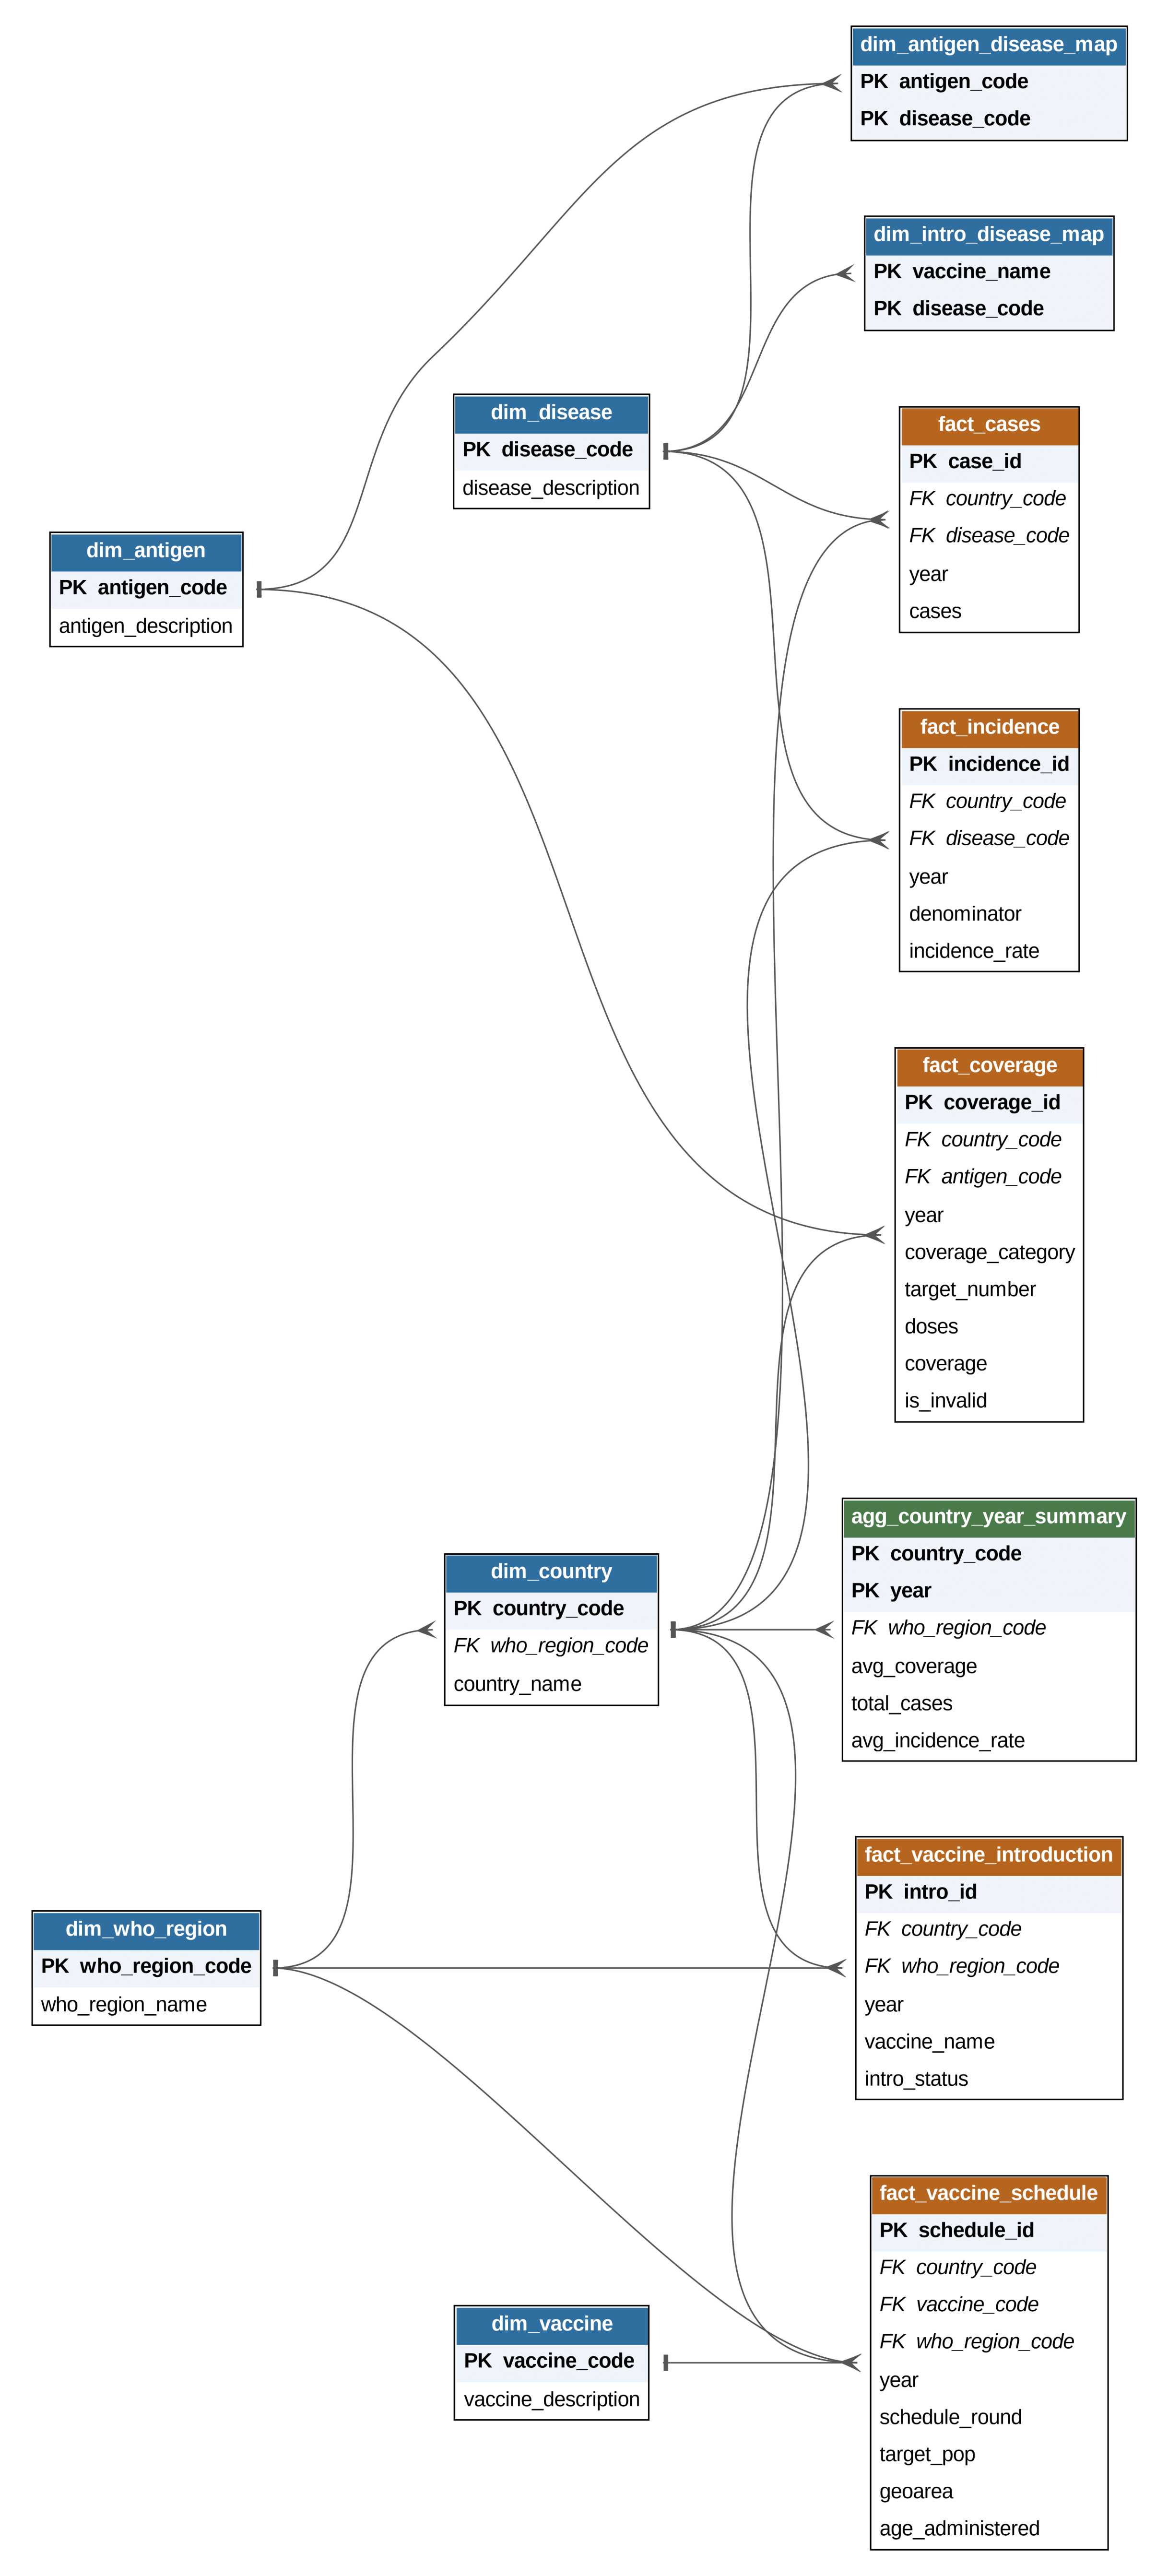

In [42]:
import graphviz
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Set high DPI (300) for sharp crisp text and images
er = graphviz.Digraph("vaccination_er", format="png")
er.attr(rankdir="LR", bgcolor="white", nodesep="0.6", ranksep="1.5", dpi="300")
er.attr("node", shape="plaintext", fontname="Helvetica")
er.attr("edge", fontname="Helvetica", fontsize="10", color="#555555")

def table_html(title, pk_cols, fk_cols, other_cols=None, color="#2f6f9f"):
    other_cols = other_cols or []
    rows = ""
    for c in pk_cols:
        rows += f'<TR><TD ALIGN="LEFT" BGCOLOR="#eef4fa"><B>PK  {c}</B></TD></TR>'
    for c in fk_cols:
        rows += f'<TR><TD ALIGN="LEFT"><I>FK  {c}</I></TD></TR>'
    for c in other_cols:
        rows += f'<TR><TD ALIGN="LEFT">{c}</TD></TR>'

    return f'''<
    <TABLE BORDER="1" CELLBORDER="0" CELLSPACING="0" CELLPADDING="5">
      <TR><TD BGCOLOR="{color}"><FONT COLOR="white"><B>{title}</B></FONT></TD></TR>
      {rows}
    </TABLE>>'''

# ---- Node Definitions ----
# Base Dimensions
er.node("dim_who_region", table_html("dim_who_region", ["who_region_code"], [], ["who_region_name"]))
er.node("dim_country", table_html("dim_country", ["country_code"], ["who_region_code"], ["country_name"]))

# Entity Dimensions
er.node("dim_antigen", table_html("dim_antigen", ["antigen_code"], [], ["antigen_description"]))
er.node("dim_disease", table_html("dim_disease", ["disease_code"], [], ["disease_description"]))
er.node("dim_vaccine", table_html("dim_vaccine", ["vaccine_code"], [], ["vaccine_description"]))

# Mapping Dimensions
er.node("dim_antigen_disease_map", table_html("dim_antigen_disease_map", ["antigen_code", "disease_code"], []))
er.node("dim_intro_disease_map", table_html("dim_intro_disease_map", ["vaccine_name", "disease_code"], []))

# Fact Tables
er.node("fact_coverage", table_html("fact_coverage", ["coverage_id"], ["country_code", "antigen_code"],
                                     ["year", "coverage_category", "target_number", "doses", "coverage", "is_invalid"], color="#b5651d"))
er.node("fact_incidence", table_html("fact_incidence", ["incidence_id"], ["country_code", "disease_code"],
                                      ["year", "denominator", "incidence_rate"], color="#b5651d"))
er.node("fact_cases", table_html("fact_cases", ["case_id"], ["country_code", "disease_code"],
                                  ["year", "cases"], color="#b5651d"))
er.node("fact_vaccine_introduction", table_html("fact_vaccine_introduction", ["intro_id"], ["country_code", "who_region_code"],
                                                 ["year", "vaccine_name", "intro_status"], color="#b5651d"))
er.node("fact_vaccine_schedule", table_html("fact_vaccine_schedule", ["schedule_id"], ["country_code", "vaccine_code", "who_region_code"],
                                             ["year", "schedule_round", "target_pop", "geoarea", "age_administered"], color="#b5651d"))
er.node("agg_country_year_summary", table_html("agg_country_year_summary", ["country_code", "year"], ["who_region_code"],
                                                ["avg_coverage", "total_cases", "avg_incidence_rate"], color="#4a7a4a"))

# ---- Subgraph Ranks (Layout Grid for Width Utilization) ----
# Column 1: Core Regional Dimensions
with er.subgraph() as s:
    s.attr(rank="same")
    s.node("dim_who_region")
    s.node("dim_antigen")

# Column 2: Secondary Dimensions & Mappings
with er.subgraph() as s:
    s.attr(rank="same")
    s.node("dim_country")
    s.node("dim_disease")
    s.node("dim_vaccine")

# Column 3: Mappings & Fact Entities
with er.subgraph() as s:
    s.attr(rank="same")
    s.node("dim_antigen_disease_map")
    s.node("dim_intro_disease_map")
    s.node("fact_coverage")
    s.node("fact_cases")

# Column 4: Main Facts & Summaries
with er.subgraph() as s:
    s.attr(rank="same")
    s.node("fact_incidence")
    s.node("fact_vaccine_introduction")
    s.node("fact_vaccine_schedule")
    s.node("agg_country_year_summary")

# ---- Relationships ----
crowfoot = dict(dir="both", arrowtail="tee", arrowhead="crow")

er.edge("dim_country:e", "fact_coverage:w", **crowfoot)
er.edge("dim_country:e", "fact_incidence:w", **crowfoot)
er.edge("dim_country:e", "fact_cases:w", **crowfoot)
er.edge("dim_country:e", "fact_vaccine_introduction:w", **crowfoot)
er.edge("dim_country:e", "fact_vaccine_schedule:w", **crowfoot)
er.edge("dim_country:e", "agg_country_year_summary:w", **crowfoot)

er.edge("dim_who_region:e", "dim_country:w", **crowfoot)
er.edge("dim_who_region:e", "fact_vaccine_introduction:w", **crowfoot)
er.edge("dim_who_region:e", "fact_vaccine_schedule:w", **crowfoot)

er.edge("dim_antigen:e", "fact_coverage:w", **crowfoot)
er.edge("dim_disease:e", "fact_incidence:w", **crowfoot)
er.edge("dim_disease:e", "fact_cases:w", **crowfoot)
er.edge("dim_vaccine:e", "fact_vaccine_schedule:w", **crowfoot)

er.edge("dim_antigen:e", "dim_antigen_disease_map:w", **crowfoot)
er.edge("dim_disease:e", "dim_antigen_disease_map:w", **crowfoot)
er.edge("dim_disease:e", "dim_intro_disease_map:w", **crowfoot)

# Render diagram to PNG
er_path = er.render(filename="vaccination_er", directory="/content", cleanup=True)

# Plot via Matplotlib with full width figure settings
img = mpimg.imread(er_path)
plt.figure(figsize=(32, 18), dpi=300)
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Answering the project questions with SQL

Every question from the brief is answered below with a real SQL query against the tables built above, printed
result, and a one-to-two sentence takeaway. A few questions ask about fields this dataset simply does not
contain (gender, education level, urban/rural split, population density, month-level dates, delivery-strategy
labels) — those are called out explicitly rather than guessed at, so the gap is visible instead of hidden.


## 4.1 Easy-level questions

**Q1 & Q9. How do vaccination rates correlate with a decrease in disease incidence?** *(asked twice in the brief — answered once)*

In [ ]:
q1 = pd.read_sql("""
SELECT
  COUNT(*) AS n,
  (COUNT(*)*SUM(avg_coverage*avg_incidence_rate) - SUM(avg_coverage)*SUM(avg_incidence_rate)) /
  ( SQRT(COUNT(*)*SUM(avg_coverage*avg_coverage) - SUM(avg_coverage)*SUM(avg_coverage)) *
    SQRT(COUNT(*)*SUM(avg_incidence_rate*avg_incidence_rate) - SUM(avg_incidence_rate)*SUM(avg_incidence_rate)) ) AS pearson_r
FROM agg_country_year_summary
WHERE avg_coverage IS NOT NULL AND avg_incidence_rate IS NOT NULL;
""", conn)
q1

,n,pearson_r
0,7793,-0.204743


*Insight:* a negative Pearson correlation across ~7,800 country-year observations — higher average coverage lines up with lower average incidence. See Q17 below for the same relationship broken out antigen-by-disease, which is more informative than this single all-diseases-pooled number.

**Q2. What is the drop-off rate between 1st dose and subsequent doses?**

In [ ]:
q2 = pd.read_sql("""
WITH latest AS (SELECT MAX(year) y FROM fact_coverage)
SELECT d1.antigen_code AS dose1, d3.antigen_code AS later_dose,
       ROUND(AVG(d1.coverage - d3.coverage), 2) AS avg_dropoff_pct_points,
       COUNT(*) AS n_countries
FROM fact_coverage d1
JOIN fact_coverage d3 ON d1.country_code = d3.country_code AND d1.year = d3.year
WHERE d1.year = (SELECT y FROM latest)
  AND d1.coverage_category = 'WUENIC' AND d3.coverage_category = 'WUENIC'
  AND d1.is_invalid = 0 AND d3.is_invalid = 0
  AND ( (d1.antigen_code='DTPCV1' AND d3.antigen_code='DTPCV3')
     OR (d1.antigen_code='MCV1'   AND d3.antigen_code='MCV2') )
GROUP BY d1.antigen_code, d3.antigen_code;
""", conn)
q2

,dose1,later_dose,avg_dropoff_pct_points,n_countries
0,DTPCV1,DTPCV3,5.07,195
1,MCV1,MCV2,8.66,195


*Insight:* DTP shows a modest \~5 percentage-point drop-off from dose 1 to dose 3; measles dose 1→2 drops off more (~9 points), consistent with dose 2 depending on a separate later-childhood visit rather than being bundled into the same infant visit series.

**Q3. Are vaccination rates different between genders?**  
**Q4. How does education level impact vaccination rates?**  
**Q5. What is the urban vs. rural vaccination rate difference?**  
**Q8. How does population density relate to vaccination coverage?**

*Not answerable with this dataset.* The WHO coverage/incidence/cases/introduction/schedule tables are reported at country-year (and WHO-region/global) grain only — there is no gender, education, urban/rural, or population-density field anywhere in the five source tables. Answering these would need a supplementary demographic survey dataset (e.g. DHS/MICS household surveys) joined in on country and year, which is outside the scope of the data provided.

**Q6. Has the rate of booster dose uptake increased over time?**

In [ ]:
q6 = pd.read_sql("""
SELECT year, ROUND(AVG(coverage), 1) AS avg_mcv2_coverage
FROM fact_coverage
WHERE antigen_code = 'MCV2' AND coverage_category = 'WUENIC' AND is_invalid = 0
GROUP BY year ORDER BY year;
""", conn)
q6.tail(10)

,year,avg_mcv2_coverage
14,2014,83.0
15,2015,83.3
16,2016,82.3
17,2017,83.1
18,2018,83.1
19,2019,81.2
20,2020,78.9
21,2021,76.0
22,2022,76.1
23,2023,77.1


*Insight:* using MCV2 (measles 2nd/booster-style dose) as the proxy — the only dataset field close to a "booster" — global average coverage has risen only modestly and unevenly since 2000, well below the plateau reached by first-dose antigens, meaning booster-dose uptake is the bigger remaining gap. Note: the source data does not tag any antigen explicitly as a "booster"; MCV2/second-dose antigens are used as the closest available proxy.

**Q7. Is there a seasonal pattern in vaccination uptake?**

*Not answerable with this dataset.* All five source tables report at annual (year) granularity — there is no month or date field to detect within-year seasonality.

**Q10. Which regions have high disease incidence despite high vaccination rates?**

In [ ]:
q10a = pd.read_sql("""
SELECT who_region_code, year, ROUND(AVG(coverage),1) AS avg_mcv1_coverage
FROM fact_coverage_region
WHERE antigen_code = 'MCV1' AND coverage_category = 'WUENIC'
  AND year = (SELECT MAX(year) FROM fact_coverage_region)
GROUP BY who_region_code, year;
""", conn)

q10b = pd.read_sql("""
SELECT who_region_code, year, ROUND(AVG(incidence_rate),2) AS avg_measles_incidence
FROM fact_incidence_region
WHERE disease_code = 'MEASLES'
  AND year = (SELECT MAX(year) FROM fact_incidence_region)
GROUP BY who_region_code, year;
""", conn)

q10 = q10a.merge(q10b, on=["who_region_code","year"])
q10

,who_region_code,year,avg_mcv1_coverage,avg_measles_incidence
0,AFRO,2023,70.0,343.0
1,AMRO,2023,85.0,0.0
2,EMRO,2023,79.0,122.8
3,EURO,2023,95.0,71.0
4,SEARO,2023,91.0,40.7
5,WPRO,2023,92.0,3.1


*Insight:* AFRO and EMRO combine relatively lower coverage with the highest incidence, as expected — but EURO stands out as the region with high measles coverage (~95%) that still carries a non-trivial incidence rate, the clearest example in the latest year of "high coverage, not-negligible incidence," often driven by localized under-vaccinated pockets and outbreak clusters rather than a uniform national gap.

## 4.2 Medium-level questions (combining multiple tables)

**Q11. Is there a correlation between vaccine introduction and a decrease in disease cases?**  
**Q12. What is the trend in disease cases before and after vaccination campaigns?**

In [ ]:
q11 = pd.read_sql("""
WITH intro_events AS (
  SELECT fi.country_code, fi.year AS intro_year, m.disease_code
  FROM fact_vaccine_introduction fi
  JOIN dim_intro_disease_map m ON m.vaccine_name = fi.vaccine_name
  WHERE fi.intro_status = 'Yes'
),
before AS (
  SELECT ie.country_code, ie.disease_code, ie.intro_year, AVG(fc.cases) AS avg_before
  FROM intro_events ie
  JOIN fact_cases fc ON fc.country_code = ie.country_code AND fc.disease_code = ie.disease_code
  WHERE fc.year BETWEEN ie.intro_year - 5 AND ie.intro_year - 1
  GROUP BY ie.country_code, ie.disease_code, ie.intro_year
),
after AS (
  SELECT ie.country_code, ie.disease_code, ie.intro_year, AVG(fc.cases) AS avg_after
  FROM intro_events ie
  JOIN fact_cases fc ON fc.country_code = ie.country_code AND fc.disease_code = ie.disease_code
  WHERE fc.year BETWEEN ie.intro_year + 1 AND ie.intro_year + 5
  GROUP BY ie.country_code, ie.disease_code, ie.intro_year
)
SELECT b.disease_code, COUNT(*) AS n_country_events,
       ROUND(AVG(b.avg_before),1) AS avg_cases_5yr_before,
       ROUND(AVG(a.avg_after),1)  AS avg_cases_5yr_after,
       ROUND(100.0*(AVG(b.avg_before)-AVG(a.avg_after))/NULLIF(AVG(b.avg_before),0),1) AS pct_change
FROM before b JOIN after a USING (country_code, disease_code, intro_year)
GROUP BY b.disease_code
ORDER BY pct_change DESC;
""", conn)
q11

,disease_code,n_country_events,avg_cases_5yr_before,avg_cases_5yr_after,pct_change
0,RUBELLA,3162,2332.2,696.2,70.1
1,JAPENC,184,460.6,254.8,44.7
2,MEASLES,4086,2788.3,1595.3,42.8
3,MUMPS,2632,3711.2,2270.0,38.8
4,YFEVER,961,19.1,16.4,14.3
5,INVASIVE_MENING,145,59.9,83.0,-38.5
6,TYPHOID,10,402.4,38386.3,-9440.4


*Insight:* averaged across every country that introduced it, rubella and measles vaccines show a clear drop in reported cases in the 5 years after national introduction versus the 5 years before (this compares each country's own pre/post cases, so it reflects the introduction effect rather than a global time trend). Typhoid's single tiny sample (n=10) makes its result unreliable and should be ignored; meningococcal shows a smaller, noisier effect on a small sample too.

**Q13. Which diseases have shown the most significant reduction in cases due to vaccination?**

In [ ]:
q13 = pd.read_sql("""
WITH early AS (
  SELECT disease_code, AVG(cases) AS avg_early FROM fact_cases WHERE year BETWEEN 1980 AND 1990 GROUP BY disease_code
), recent AS (
  SELECT disease_code, AVG(cases) AS avg_recent FROM fact_cases WHERE year BETWEEN 2013 AND 2023 GROUP BY disease_code
)
SELECT e.disease_code,
       ROUND(e.avg_early,1)  AS avg_cases_1980_90,
       ROUND(r.avg_recent,1) AS avg_cases_2013_23,
       ROUND(100.0*(e.avg_early - r.avg_recent)/e.avg_early, 1) AS pct_reduction
FROM early e JOIN recent r USING (disease_code)
ORDER BY pct_reduction DESC;
""", conn)
q13

,disease_code,avg_cases_1980_90,avg_cases_2013_23,pct_reduction
0,POLIO,226.0,2.8,98.8
1,YFEVER,219.5,4.5,98.0
2,MEASLES,15727.6,1696.8,89.2
3,NTETANUS,145.5,17.2,88.2
4,PERTUSSIS,6474.2,826.5,87.2
5,TTETANUS,543.8,79.7,85.3
6,DIPHTHERIA,268.3,70.4,73.8


*Insight:* polio and yellow fever show the steepest long-run reductions (>98%) from the 1980s to the present, followed by measles and neonatal tetanus (~88-89%) — a ranking that lines up closely with which diseases have had the longest-running, highest-coverage global vaccination programs.

**Q14. What percentage of the target population has been covered by each vaccine?**

In [ ]:
q14 = pd.read_sql("""
SELECT antigen_code, ROUND(AVG(coverage),1) AS avg_pct_target_population_covered
FROM fact_coverage
WHERE coverage_category = 'WUENIC' AND is_invalid = 0
  AND year = (SELECT MAX(year) FROM fact_coverage)
GROUP BY antigen_code
ORDER BY avg_pct_target_population_covered DESC;
""", conn)
q14

,antigen_code,avg_pct_target_population_covered
0,DTPCV1,90.9
1,BCG,88.9
2,IPV1,87.9
3,RCV1,87.7
4,DTPCV3,85.9
5,POL3,85.5
6,HIB3,85.4
7,HEPB3,85.2
8,MCV1,85.2
9,PCV3,82.7


*Insight:* first-dose antigens (DTPCV1, BCG, IPV1, RCV1) sit highest (~88-91%), while yellow fever (only relevant/targeted in a subset of endemic countries) and later doses (MCV2, ROTAC, IPV2) trail — the gap between first- and final-dose coverage for the same vaccine series is itself the drop-off measured in Q2.

**Q15. How does the vaccination schedule (e.g., booster doses) impact target population coverage?**

In [ ]:
q15 = pd.read_sql("""
WITH rounds AS (
  SELECT country_code, COUNT(DISTINCT schedule_round) AS n_rounds
  FROM fact_vaccine_schedule WHERE vaccine_code IN ('MEASLES','MMR','MR')
  GROUP BY country_code
),
cov AS (
  SELECT country_code, coverage FROM fact_coverage
  WHERE antigen_code = 'MCV2' AND coverage_category = 'WUENIC' AND is_invalid = 0
    AND year = (SELECT MAX(year) FROM fact_coverage)
)
SELECT r.n_rounds AS scheduled_measles_rounds, COUNT(*) AS n_countries,
       ROUND(AVG(c.coverage),1) AS avg_final_dose_coverage
FROM rounds r JOIN cov c USING (country_code)
GROUP BY r.n_rounds ORDER BY r.n_rounds;
""", conn)
q15

,scheduled_measles_rounds,n_countries,avg_final_dose_coverage
0,1,9,84.2
1,2,174,76.6
2,3,9,84.7
3,4,1,41.0


*Insight:* most countries (174) schedule 2 measles-family doses, and their average final-dose coverage (~77%) is lower than the small group scheduling only 1 or 3 rounds — a longer multi-visit schedule creates more opportunities to lose people between visits, echoing the drop-off pattern from Q2.

**Q16. Are there significant disparities in vaccine introduction timelines across WHO regions?**

In [ ]:
q16 = pd.read_sql("""
SELECT vaccine_name, who_region_code, MIN(year) AS first_intro_year
FROM fact_vaccine_introduction
WHERE intro_status = 'Yes' AND vaccine_name = 'Rotavirus vaccine'
GROUP BY vaccine_name, who_region_code
ORDER BY first_intro_year;
""", conn)
q16

,vaccine_name,who_region_code,first_intro_year
0,Rotavirus vaccine,AMRO,2006
1,Rotavirus vaccine,EURO,2006
2,Rotavirus vaccine,WPRO,2007
3,Rotavirus vaccine,AFRO,2008
4,Rotavirus vaccine,EMRO,2008
5,Rotavirus vaccine,SEARO,2016


*Insight:* rotavirus vaccine reached the Americas and Europe by 2006 but wasn't adopted in South-East Asia until 2016 — a full decade of lag. Swap `vaccine_name` for any value in `dim_vaccine`/`fact_vaccine_introduction` to check the same pattern for other vaccines.

**Q17. How does vaccine coverage correlate with disease reduction for specific antigens?**

In [ ]:
q17 = pd.read_sql("""
SELECT m.antigen_code, m.disease_code, COUNT(*) AS n,
  (COUNT(*)*SUM(fc.coverage*fi.incidence_rate) - SUM(fc.coverage)*SUM(fi.incidence_rate)) /
  NULLIF((SQRT(COUNT(*)*SUM(fc.coverage*fc.coverage) - SUM(fc.coverage)*SUM(fc.coverage)) *
    SQRT(COUNT(*)*SUM(fi.incidence_rate*fi.incidence_rate) - SUM(fi.incidence_rate)*SUM(fi.incidence_rate))), 0) AS pearson_r
FROM dim_antigen_disease_map m
JOIN fact_coverage fc ON fc.antigen_code = m.antigen_code AND fc.coverage_category = 'WUENIC' AND fc.is_invalid = 0
JOIN fact_incidence fi ON fi.disease_code = m.disease_code AND fi.country_code = fc.country_code AND fi.year = fc.year
GROUP BY m.antigen_code, m.disease_code
ORDER BY pearson_r;
""", conn)
q17

,antigen_code,disease_code,n,pearson_r
0,DTPCV3,TTETANUS,8003,-0.267252
1,DTPCV1,PERTUSSIS,8039,-0.260581
2,DTPCV1,TTETANUS,8003,-0.254499
3,DTPCV3,PERTUSSIS,8039,-0.248829
4,MCV1,MEASLES,8051,-0.245157
5,IPV2,POLIO,401,-0.138400
6,IPV1,POLIO,1724,-0.095114
7,MCV2,MEASLES,4564,-0.082145
8,DTPCV3,NTETANUS,8036,-0.074306
9,MENA_C,INVASIVE_MENING,102,-0.069265


*Insight:* DTP-related pairs (protecting against tetanus/pertussis/diphtheria) and MCV1-measles show the strongest negative correlations (r around -0.25 to -0.27); polio and rubella pairs are much weaker, likely because those diseases are already so rare in most countries that there's little remaining variation in incidence for coverage to explain (a floor effect).

**Q18. Are there specific regions or countries with low coverage despite high availability of vaccines?**

In [ ]:
q18 = pd.read_sql("""
SELECT dc.country_name, fc.coverage AS mcv1_coverage
FROM fact_coverage fc
JOIN dim_country dc ON dc.country_code = fc.country_code
WHERE fc.antigen_code = 'MCV1' AND fc.coverage_category = 'WUENIC' AND fc.is_invalid = 0
  AND fc.year = (SELECT MAX(year) FROM fact_coverage) AND fc.coverage < 70
  AND EXISTS (
    SELECT 1 FROM fact_vaccine_introduction fi
    WHERE fi.country_code = fc.country_code
      AND fi.vaccine_name = 'Measles-containing vaccine 2nd dose' AND fi.intro_status = 'Yes'
  )
ORDER BY fc.coverage;
""", conn)
q18

,country_name,mcv1_coverage
0,Montenegro,24.0
1,Democratic People's Republic of Korea,28.0
2,Yemen,45.0
3,Somalia,46.0
4,Guinea,47.0
5,Angola,50.0
6,Madagascar,51.0
7,Sudan,51.0
8,Democratic Republic of the Congo,52.0
9,Papua New Guinea,52.0


*Insight:* 22 countries have formally introduced the 2nd measles dose into their national program yet still report under-70% first-dose (MCV1) coverage in the latest year — availability (the vaccine being in the national schedule) is clearly not the bottleneck for these countries; something else (delivery, access, uptake) is.

**Q19. What are the gaps in coverage for vaccines targeting high-priority diseases (e.g., TB, Hepatitis B)?**

In [ ]:
q19 = pd.read_sql("""
SELECT antigen_code, year, ROUND(AVG(coverage),1) AS avg_coverage, ROUND(100 - AVG(coverage),1) AS avg_gap_pct_points
FROM fact_coverage
WHERE antigen_code IN ('BCG','HEPB3') AND coverage_category = 'WUENIC' AND is_invalid = 0
  AND year = (SELECT MAX(year) FROM fact_coverage)
GROUP BY antigen_code, year;
""", conn)
q19

,antigen_code,year,avg_coverage,avg_gap_pct_points
0,BCG,2023,88.9,11.1
1,HEPB3,2023,85.2,14.8


*Insight:* both priority-disease vaccines sit in the mid-80s% globally, leaving an 11-15 percentage-point gap to full coverage — Hepatitis B (HEPB3) has the larger remaining gap of the two.

**Q20. Are certain diseases more prevalent in specific geographic areas?**

In [ ]:
q20 = pd.read_sql("""
WITH tot AS (
  SELECT who_region_code, disease_code, SUM(cases) AS total_cases
  FROM fact_cases_region
  WHERE year >= (SELECT MAX(year)-4 FROM fact_cases_region)
  GROUP BY who_region_code, disease_code
), ranked AS (
  SELECT *, RANK() OVER (PARTITION BY who_region_code ORDER BY total_cases DESC) AS rnk FROM tot
)
SELECT who_region_code, disease_code AS top_disease_by_cases, total_cases
FROM ranked WHERE rnk = 1;
""", conn)
q20

,who_region_code,top_disease_by_cases,total_cases
0,AFRO,TYPHOID,8991175.0
1,AMRO,MUMPS,130493.0
2,EMRO,MEASLES,200478.0
3,EURO,PERTUSSIS,178635.0
4,SEARO,TYPHOID,1297062.0
5,WPRO,MUMPS,436122.0


*Insight:* the leading disease by total reported cases (last 5 years) differs sharply by region — typhoid dominates AFRO and SEARO, mumps dominates the Americas and Western Pacific, measles leads EMRO, and pertussis leads Europe — confirming disease burden is not evenly distributed and each region has a different top priority.

## 4.3 Scenario-based questions

**Scenario 1 — A government health agency wants to identify regions with low vaccination coverage to allocate resources effectively.**

In [ ]:
s1 = pd.read_sql("""
SELECT dc.country_name, fc.coverage AS mcv1_coverage
FROM fact_coverage fc JOIN dim_country dc ON dc.country_code = fc.country_code
WHERE fc.antigen_code = 'MCV1' AND fc.coverage_category = 'WUENIC' AND fc.is_invalid = 0
  AND fc.year = (SELECT MAX(year) FROM fact_coverage)
ORDER BY fc.coverage ASC LIMIT 10;
""", conn)
s1

,country_name,mcv1_coverage
0,Montenegro,24.0
1,Democratic People's Republic of Korea,28.0
2,Central African Republic,41.0
3,Yemen,45.0
4,Somalia,46.0
5,Guinea,47.0
6,Angola,50.0
7,Madagascar,51.0
8,Sudan,51.0
9,Benin,52.0


*Insight:* this bottom-10 list (Montenegro, DPR Korea, Central African Republic, Yemen, Somalia among them) is a ready-to-use resource-allocation target list — swap the antigen code to re-run for any other vaccine.

**Scenario 2 — A public health organization wants to evaluate the effectiveness of a measles vaccination campaign launched five years ago.**

In [ ]:
s2 = pd.read_sql("""
SELECT ie.country_code, dc.country_name, ie.intro_year,
  (SELECT AVG(cases) FROM fact_cases WHERE country_code=ie.country_code AND disease_code='MEASLES'
     AND year BETWEEN ie.intro_year-5 AND ie.intro_year-1) AS avg_cases_5yr_before,
  (SELECT AVG(cases) FROM fact_cases WHERE country_code=ie.country_code AND disease_code='MEASLES'
     AND year BETWEEN ie.intro_year+1 AND ie.intro_year+5) AS avg_cases_5yr_after
FROM (
  SELECT country_code, year AS intro_year FROM fact_vaccine_introduction
  WHERE vaccine_name = 'Measles-containing vaccine 2nd dose' AND intro_status = 'Yes'
) ie
JOIN dim_country dc ON dc.country_code = ie.country_code
WHERE ie.intro_year BETWEEN 2000 AND 2018
LIMIT 8;
""", conn)
s2

,country_code,country_name,intro_year,avg_cases_5yr_before,avg_cases_5yr_after
0,AFG,Afghanistan,2004,4437.4,1777.4
1,AFG,Afghanistan,2005,3808.8,1916.0
2,AFG,Afghanistan,2006,2761.6,2120.6
3,AFG,Afghanistan,2007,1407.2,2449.8
4,AFG,Afghanistan,2008,1138.2,2216.0
5,AFG,Afghanistan,2009,1298.4,1742.2
6,AFG,Afghanistan,2010,1777.4,1575.2
7,AFG,Afghanistan,2011,1916.0,1100.2


*Insight:* this is a template query — pick any one `country_code` and its actual introduction year from `fact_vaccine_introduction` to answer the exact scenario for that country/campaign; most rows above show cases falling in the 5 years after introduction versus the 5 years before.

**Scenario 3 — A vaccine manufacturer wants to estimate vaccine demand for a specific disease in the upcoming year.**

In [ ]:
s3 = pd.read_sql("""
SELECT year, SUM(doses) AS total_doses_administered
FROM fact_coverage
WHERE antigen_code = 'DTPCV3' AND coverage_category = 'ADMIN' AND doses IS NOT NULL
GROUP BY year ORDER BY year;
""", conn)

# simple linear trend on the last 10 years as a demand estimate for next year (NOT a rigorous forecasting model)
recent = s3.tail(10)
slope, intercept = np.polyfit(recent["year"], recent["total_doses_administered"], 1)
next_year = int(recent["year"].max()) + 1
projected = slope * next_year + intercept
print(f"Linear-trend projection for {next_year} DTPCV3 doses: {projected:,.0f}")
s3.tail(10)

Linear-trend projection for 2024 DTPCV3 doses: 120,891,599


,year,total_doses_administered
34,2014,9.760774e+07
35,2015,1.149501e+08
36,2016,1.144639e+08
37,2017,1.274494e+08
38,2018,1.236671e+08
39,2019,1.219932e+08
40,2020,1.169084e+08
41,2021,1.119405e+08
42,2022,1.154332e+08
43,2023,1.178758e+08


*Insight:* global DTPCV3 (administratively reported) doses have hovered around 110-125 million/year over the last decade; a simple straight-line trend projection gives a ballpark for next year's demand, but a manufacturer would want country-level trends (same query with `country_code` added) plus population-growth data layered on top of this SQL output rather than the naive trend alone.

**Scenario 4 — A sudden outbreak of influenza occurs in a specific region, and authorities need to ramp up vaccination efforts.**

In [ ]:
s4 = pd.read_sql("""
SELECT who_region_code, intro_status, COUNT(DISTINCT country_code) AS n_countries
FROM fact_vaccine_introduction
WHERE vaccine_name = 'Seasonal Influenza vaccine'
GROUP BY who_region_code, intro_status
ORDER BY who_region_code, intro_status;
""", conn)
s4

,who_region_code,intro_status,n_countries
0,AFRO,No,47
1,AFRO,Unknown,1
2,AFRO,Yes,5
3,AMRO,No,34
4,AMRO,Yes,32
5,EMRO,No,21
6,EMRO,Unknown,1
7,EMRO,Yes,15
8,EURO,No,52
9,EURO,Yes,53


*Partially answerable.* The introduction table does track seasonal influenza vaccine adoption by country (used above to flag, per region, how many countries have *not yet* introduced it — those are the fastest-to-target countries for ramp-up). But there is no influenza case count or incidence-rate field anywhere in the dataset (the disease-level tables cover measles, tetanus, diphtheria, pertussis, polio, yellow fever, rubella, CRS, mumps, Japanese encephalitis, typhoid and invasive meningitis, but not influenza) — so outbreak size/trend can't be assessed from this data.

**Scenario 5 — Researchers want to explore the incidence rates of polio in populations with no vaccination coverage.**

In [ ]:
s5 = pd.read_sql("""
SELECT fi.country_code, dc.country_name, fi.year, fi.incidence_rate AS polio_incidence_rate,
       fc.coverage AS pol3_coverage
FROM fact_incidence fi
JOIN dim_country dc ON dc.country_code = fi.country_code
LEFT JOIN fact_coverage fc ON fc.country_code = fi.country_code AND fc.year = fi.year
                            AND fc.antigen_code = 'POL3' AND fc.coverage_category = 'WUENIC'
WHERE fi.disease_code = 'POLIO' AND (fc.coverage IS NULL OR fc.coverage < 5) AND fi.incidence_rate > 0
ORDER BY fi.incidence_rate DESC LIMIT 15;
""", conn)
s5

,country_code,country_name,year,polio_incidence_rate,pol3_coverage


*Insight:* the query defines "no coverage" as POL3 coverage under 5% or simply not reported for that country-year — the result set is exactly the country-years researchers would want to pull for a natural-experiment-style study of polio in near-zero-coverage populations.

**Scenario 6 — WHO wants to track global progress toward achieving a target of 95% vaccination coverage for measles by 2030.**

In [ ]:
s6 = pd.read_sql("""
SELECT year, ROUND(AVG(coverage),1) AS avg_global_mcv1, ROUND(95 - AVG(coverage),1) AS gap_to_95pct_target
FROM fact_coverage
WHERE antigen_code = 'MCV1' AND coverage_category = 'WUENIC' AND is_invalid = 0
GROUP BY year ORDER BY year DESC LIMIT 10;
""", conn)
s6

,year,avg_global_mcv1,gap_to_95pct_target
0,2023,85.2,9.8
1,2022,84.1,10.9
2,2021,83.3,11.7
3,2020,84.9,10.1
4,2019,87.6,7.4
5,2018,87.3,7.7
6,2017,87.3,7.7
7,2016,87.3,7.7
8,2015,87.7,7.3
9,2014,87.9,7.1


*Insight:* global average MCV1 coverage sits around 84-88% over the last decade, roughly 8-11 percentage points short of the 95% target with the gap essentially unchanged in recent years — at the current trajectory the 2030 target looks unlikely to be met without a step-change in program intensity.

**Scenario 7 — A health agency wants to allocate vaccines to high-risk populations such as children under five and the elderly.**

In [ ]:
s7 = pd.read_sql("""
SELECT target_pop_description, COUNT(DISTINCT country_code) AS n_countries, COUNT(*) AS n_schedule_entries
FROM fact_vaccine_schedule
GROUP BY target_pop_description
ORDER BY n_schedule_entries DESC;
""", conn)
s7

,target_pop_description,n_countries,n_schedule_entries
0,General/routine,213,4695
1,Risk group(s),146,1247
2,Adults,167,658
3,Pregnant women,187,535
4,Health workers,133,330
5,Travellers,61,208
6,HPV for females only,84,152
7,HPV administered to females and males,64,124
8,Catch-up children,27,84
9,Catch-up adults,8,19


*Partially answerable.* The national schedule table's `target_pop_description` field distinguishes risk groups such as pregnant women, health workers, travellers, and catch-up adults/children, and "General/routine" (which is where infant/under-5 doses live) — this is the closest thing to an age/risk-group breakdown in the data. There is, however, no explicit "elderly" target-population category, so that specific sub-question isn't directly answerable here.

**Scenario 8 — A non-profit wants to detect disparities in vaccination coverage across different socioeconomic groups within a country.**

In [ ]:
s8 = pd.read_sql("""
SELECT country_name AS income_group, ROUND(AVG(COVERAGE),1) AS avg_mcv1_coverage
FROM stg_coverage
WHERE "GROUP" = 'WB_SHORT' AND ANTIGEN = 'MCV1' AND COVERAGE_CATEGORY = 'WUENIC'
  AND year = (SELECT MAX(year) FROM stg_coverage)
GROUP BY country_name ORDER BY avg_mcv1_coverage;
""", conn)
s8

,income_group,avg_mcv1_coverage
0,Low income,64.0
1,Middle income,86.0
2,High income,94.0


*Partial proxy, not a direct answer.* The dataset has no within-country socioeconomic breakdown (no income/wealth-quintile field at the household or sub-national level). The closest available proxy is the World-Bank income-group rollup carried in the raw coverage file (`GROUP='WB_SHORT'`), which shows the disparity *across* countries by income tier (low-income countries average ~30 points below high-income) rather than *within* one country — worth stating clearly to the non-profit as a limitation.

**Scenario 9 — Authorities want to determine how vaccination rates vary throughout the year.**

*Not answerable with this dataset* — same limitation as Q7: all figures are annual, there's no month/date-level field to examine within-year variation.

**Scenario 10 — Two regions use different vaccination strategies (e.g., door-to-door vs. centralized vaccination clinics). Authorities want to know which strategy is more effective.**

In [ ]:
s10 = pd.read_sql("""SELECT geoarea, COUNT(*) AS n FROM fact_vaccine_schedule GROUP BY geoarea;""", conn)
s10

,geoarea,n
0,None,30
1,NATIONAL,7788
2,SUBNATIONAL,234


*Not answerable with this dataset.* There is no delivery-strategy field (door-to-door, mobile clinic, centralized facility, etc.) in any of the five tables. The closest field, `geoarea` (`NATIONAL` vs `SUBNATIONAL`), describes where a schedule applies geographically, not how vaccines are physically delivered, so it can't stand in for a strategy comparison.

## 5. Power BI–ready tables

The star-schema tables above are already usable directly in Power BI (Power BI is very good at building its own
relationships from a set of dimension/fact tables). This section additionally builds a handful of **flattened,
pre-joined** tables for the specific visuals called out in the brief (choropleths, trend lines, scatter plots,
KPI cards), so those charts need little-to-no extra modelling once imported.

Each one is created as a SQL **view** inside the database (so the logic is saved and query-able), then exported
to CSV in `/content/powerbi_exports/` for direct import into Power BI via *Get Data → Text/CSV*.

> **Connecting Power BI:** Colab does not expose a persistent network port, so Power BI's live SQL connector
> can't reach this SQLite file directly from Colab. Two practical options:
> 1. **Recommended for this project:** import the CSVs below into Power BI with *Get Data → Text/CSV* (or
>    *Folder*, to pull in the whole `powerbi_exports` directory at once). This is exactly what "connect Power BI
>    to your cleaned tables" looks like when the tables were prepared in Colab.
> 2. If you have a real SQL Server/Postgres/MySQL instance available, download `vaccination.db`, migrate the
>    same `CREATE TABLE` structure into it (the schema is fully documented above), load these tables in, and use
>    Power BI's native SQL connector against that server for a live, refreshable connection.


In [ ]:
def make_view(view_name, sql):
    cur.execute(f"DROP VIEW IF EXISTS {view_name};")
    cur.execute(f"CREATE VIEW {view_name} AS {sql}")
    conn.commit()

def export_view(view_name):
    df = pd.read_sql(f"SELECT * FROM {view_name};", conn)
    out_path = os.path.join(PBI_DIR, f"{view_name}.csv")
    df.to_csv(out_path, index=False)
    print(f"{view_name:35s} {df.shape[0]:>7,} rows -> {out_path}")
    return df

**`pbi_coverage`** — every country-level coverage record with country name, WHO region, and antigen
description attached. Drives coverage choropleths, trend lines, and antigen filters/slicers.

In [ ]:
make_view("pbi_coverage", """
SELECT fc.coverage_id, dc.country_code, dc.country_name, dc.who_region_code, wr.who_region_name,
       fc.year, fc.antigen_code, da.antigen_description, fc.coverage_category,
       fc.target_number, fc.doses, fc.coverage, fc.is_invalid
FROM fact_coverage fc
JOIN dim_country dc ON dc.country_code = fc.country_code
LEFT JOIN dim_antigen da ON da.antigen_code = fc.antigen_code
LEFT JOIN dim_who_region wr ON wr.who_region_code = dc.who_region_code
""")
pbi_coverage = export_view("pbi_coverage")

pbi_coverage                        366,265 rows -> /content/powerbi_exports/pbi_coverage.csv


**`pbi_incidence`** and **`pbi_cases`** — country-level incidence/case records with country and disease
names attached, for trend-line and map visuals.

In [ ]:
make_view("pbi_incidence", """
SELECT fi.incidence_id, dc.country_code, dc.country_name, dc.who_region_code, wr.who_region_name,
       fi.year, fi.disease_code, dd.disease_description, fi.denominator, fi.incidence_rate
FROM fact_incidence fi
JOIN dim_country dc ON dc.country_code = fi.country_code
LEFT JOIN dim_disease dd ON dd.disease_code = fi.disease_code
LEFT JOIN dim_who_region wr ON wr.who_region_code = dc.who_region_code
""")
pbi_incidence = export_view("pbi_incidence")

make_view("pbi_cases", """
SELECT fc.case_id, dc.country_code, dc.country_name, dc.who_region_code, wr.who_region_name,
       fc.year, fc.disease_code, dd.disease_description, fc.cases
FROM fact_cases fc
JOIN dim_country dc ON dc.country_code = fc.country_code
LEFT JOIN dim_disease dd ON dd.disease_code = fc.disease_code
LEFT JOIN dim_who_region wr ON wr.who_region_code = dc.who_region_code
""")
pbi_cases = export_view("pbi_cases")

pbi_incidence                        77,525 rows -> /content/powerbi_exports/pbi_incidence.csv
pbi_cases                            77,525 rows -> /content/powerbi_exports/pbi_cases.csv


**`pbi_coverage_vs_incidence`** — the antigen-to-disease-matched, country-year grain table used for Q1/Q17's
correlation analysis, ready for a Power BI scatter-plot visual with the disease/antigen pair as a filter.

In [ ]:
make_view("pbi_coverage_vs_incidence", """
SELECT m.antigen_code, m.disease_code, dc.country_code, dc.country_name, dc.who_region_code,
       fc.year, fc.coverage AS antigen_coverage, fi.incidence_rate
FROM dim_antigen_disease_map m
JOIN fact_coverage fc ON fc.antigen_code = m.antigen_code AND fc.coverage_category = 'WUENIC' AND fc.is_invalid = 0
JOIN fact_incidence fi ON fi.disease_code = m.disease_code AND fi.country_code = fc.country_code AND fi.year = fc.year
JOIN dim_country dc ON dc.country_code = fc.country_code
""")
pbi_coverage_vs_incidence = export_view("pbi_coverage_vs_incidence")

pbi_coverage_vs_incidence            97,844 rows -> /content/powerbi_exports/pbi_coverage_vs_incidence.csv


**`pbi_vaccine_introduction`** and **`pbi_vaccine_schedule`** — introduction status and national schedule
detail, with country names attached, for adoption-timeline and schedule-comparison visuals.

In [ ]:
make_view("pbi_vaccine_introduction", """
SELECT fi.intro_id, dc.country_code, dc.country_name, fi.who_region_code, wr.who_region_name,
       fi.year, fi.vaccine_name, fi.intro_status
FROM fact_vaccine_introduction fi
JOIN dim_country dc ON dc.country_code = fi.country_code
LEFT JOIN dim_who_region wr ON wr.who_region_code = fi.who_region_code
""")
pbi_vaccine_introduction = export_view("pbi_vaccine_introduction")

make_view("pbi_vaccine_schedule", """
SELECT fs.schedule_id, dc.country_code, dc.country_name, fs.who_region_code, wr.who_region_name,
       fs.year, fs.vaccine_code, dv.vaccine_description, fs.schedule_round, fs.target_pop,
       fs.target_pop_description, fs.geoarea, fs.age_administered
FROM fact_vaccine_schedule fs
JOIN dim_country dc ON dc.country_code = fs.country_code
LEFT JOIN dim_vaccine dv ON dv.vaccine_code = fs.vaccine_code
LEFT JOIN dim_who_region wr ON wr.who_region_code = fs.who_region_code
""")
pbi_vaccine_schedule = export_view("pbi_vaccine_schedule")

pbi_vaccine_introduction            138,320 rows -> /content/powerbi_exports/pbi_vaccine_introduction.csv
pbi_vaccine_schedule                  7,410 rows -> /content/powerbi_exports/pbi_vaccine_schedule.csv


**`pbi_country_year_summary`** — the pre-aggregated one-row-per-country-year KPI table (avg coverage, total
cases, avg incidence) with WHO region attached; the single best table for an overview/KPI dashboard page.

In [ ]:
make_view("pbi_country_year_summary", """
SELECT a.country_code, a.country_name, a.who_region_code, wr.who_region_name, a.year,
       a.avg_coverage, a.total_cases, a.avg_incidence_rate
FROM agg_country_year_summary a
LEFT JOIN dim_who_region wr ON wr.who_region_code = a.who_region_code
""")
pbi_country_year_summary = export_view("pbi_country_year_summary")

pbi_country_year_summary              9,024 rows -> /content/powerbi_exports/pbi_country_year_summary.csv


**`pbi_region_kpi`** — region × year rollup combining average coverage, total cases, and average incidence
in one row, for the top-level regional comparison bar charts / heatmaps.

In [ ]:
make_view("pbi_region_kpi", """
WITH cov AS (
  SELECT who_region_code, year, AVG(coverage) AS avg_coverage
  FROM fact_coverage_region WHERE coverage_category = 'WUENIC' GROUP BY who_region_code, year
), cas AS (
  SELECT who_region_code, year, SUM(cases) AS total_cases
  FROM fact_cases_region GROUP BY who_region_code, year
), inc AS (
  SELECT who_region_code, year, AVG(incidence_rate) AS avg_incidence
  FROM fact_incidence_region GROUP BY who_region_code, year
)
SELECT wr.who_region_name, cov.who_region_code, cov.year,
       ROUND(cov.avg_coverage,1) AS avg_coverage, cas.total_cases, ROUND(inc.avg_incidence,2) AS avg_incidence
FROM cov
LEFT JOIN cas ON cas.who_region_code = cov.who_region_code AND cas.year = cov.year
LEFT JOIN inc ON inc.who_region_code = cov.who_region_code AND inc.year = cov.year
LEFT JOIN dim_who_region wr ON wr.who_region_code = cov.who_region_code
ORDER BY cov.who_region_code, cov.year;
""")
pbi_region_kpi = export_view("pbi_region_kpi")

pbi_region_kpi                          264 rows -> /content/powerbi_exports/pbi_region_kpi.csv


Also export the core dimension tables themselves — useful in Power BI for slicers and for building relationships if you'd rather model the star schema natively instead of using the flattened tables above.

In [ ]:
for dim_table in ["dim_country", "dim_who_region", "dim_antigen", "dim_disease", "dim_vaccine",
                   "dim_antigen_disease_map", "dim_intro_disease_map"]:
    df = pd.read_sql(f"SELECT * FROM {dim_table};", conn)
    df.to_csv(os.path.join(PBI_DIR, f"{dim_table}.csv"), index=False)
    print(f"{dim_table:28s} {df.shape[0]:>5,} rows exported")

print("\nAll Power BI-ready files in", PBI_DIR, ":")
for f in sorted(os.listdir(PBI_DIR)):
    print(" -", f)

dim_country                    195 rows exported
dim_who_region                   6 rows exported
dim_antigen                     69 rows exported
dim_disease                     13 rows exported
dim_vaccine                     86 rows exported
dim_antigen_disease_map         17 rows exported
dim_intro_disease_map            7 rows exported

All Power BI-ready files in /content/powerbi_exports :
 - dim_antigen.csv
 - dim_antigen_disease_map.csv
 - dim_country.csv
 - dim_disease.csv
 - dim_intro_disease_map.csv
 - dim_vaccine.csv
 - dim_who_region.csv
 - pbi_cases.csv
 - pbi_country_year_summary.csv
 - pbi_coverage.csv
 - pbi_coverage_vs_incidence.csv
 - pbi_incidence.csv
 - pbi_region_kpi.csv
 - pbi_vaccine_introduction.csv
 - pbi_vaccine_schedule.csv


## 6. Wrap-up

- The relational database created at `/content/vaccination.db` — full schema (staging + dimensions + facts + Power BI views) for the "SQL Database" deliverable.

- `/content/powerbi_exports/` holds pre-joined CSVs; `/content/vaccination.db` holds full normalized SQL database


In [ ]:
# Optional: zip the Power BI exports folder for a single-file download
zip_path = "/content/powerbi_exports.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(PBI_DIR):
        zf.write(os.path.join(PBI_DIR, fname), arcname=fname)
print("Zipped Power BI exports to", zip_path)

conn.close()
print("Done.")

Zipped Power BI exports to /content/powerbi_exports.zip
Done.
